# 3D RRT Motion Planner for UAV
## Pure Python Implementation with Interactive Visualization

A self-contained Rapidly-exploring Random Tree (RRT) planner that finds collision-free 3D flight trajectories for UAVs inside bounded airspace with cuboid obstacles.

### Features
- Goal-biased uniform sampling (10% bias toward goal)
- Modular steer local planner
- Geometric axis-aligned bounding-box collision checking with 1.5 m safety buffer
- Cumulative cost tracking
- Full matplotlib 3D visualization

## 1. Import Libraries

In [19]:
import math
import random

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

## 2. Airspace Configuration

Define the bounded airspace, obstacles, and RRT parameters.

In [20]:
# Global airspace configuration
X_MAX = 100.0            # Airspace width   (metres)
Y_MAX = 100.0            # Airspace depth   (metres)
Z_MAX = 30.0             # Airspace ceiling (metres)

STEP_SIZE = 5.0          # Maximum expansion distance per iteration (metres)
GOAL_SAMPLE_RATE = 0.10  # Probability of sampling the goal directly (10%)
GOAL_THRESHOLD = 5.0     # Distance at which the goal counts as reached (metres)
MAX_ITER = 200           # Iteration budget
INFLATION = 1.5          # Obstacle inflation buffer for clearance (metres)

# Obstacle list. Each cuboid is (x_min, y_min, z_min, x_max, y_max, z_max).
OBSTACLES = [
    (20.0, 20.0,  0.0, 40.0, 40.0, 25.0),
    (60.0, 50.0,  0.0, 75.0, 70.0, 30.0),
    (45.0, 10.0,  0.0, 55.0, 60.0, 15.0),
]

print("Airspace configured:")
print(f"  Bounds: {X_MAX} x {Y_MAX} x {Z_MAX} m")
print(f"  Obstacles: {len(OBSTACLES)} cuboids with {INFLATION} m safety buffer")
print(f"  Max iterations: {MAX_ITER}")

Airspace configured:
  Bounds: 100.0 x 100.0 x 30.0 m
  Obstacles: 3 cuboids with 1.5 m safety buffer
  Max iterations: 200


## 3. Node Class

A single vertex in the RRT search tree.

In [21]:
class Node:
    """A single vertex in the RRT search tree."""

    def __init__(self, x, y, z):
        self.x = x
        self.y = y
        self.z = z
        self.parent = None   # Parent Node reference (None for the root/start)
        self.cost = 0.0      # Cumulative path cost from the start node

## 4. Core RRT Functions

### 4.1 Distance Calculation

In [22]:
def hitung_jarak(node_a, node_b):
    """Euclidean distance between two nodes (hitung jarak = 'compute distance')."""
    return math.sqrt(
        (node_a.x - node_b.x) ** 2
        + (node_a.y - node_b.y) ** 2
        + (node_a.z - node_b.z) ** 2
    )

### 4.2 Random Node Sampling with Goal Bias

In [23]:
def get_random_node(goal):
    """
    Draw a sample node.

    With GOAL_SAMPLE_RATE probability the goal itself is returned (goal
    biasing). Otherwise a point is drawn uniformly across the airspace.
    """
    if random.random() < GOAL_SAMPLE_RATE:
        return Node(goal.x, goal.y, goal.z)
    return Node(
        random.uniform(0.0, X_MAX),
        random.uniform(0.0, Y_MAX),
        random.uniform(0.0, Z_MAX),
    )

### 4.3 Nearest Neighbor Search

In [24]:
def get_nearest_node_id(node_list, rnd_node):
    """Return the index of the node in `node_list` closest to `rnd_node`."""
    distances = [hitung_jarak(n, rnd_node) for n in node_list]
    return distances.index(min(distances))

### 4.4 Local Planner (Steer)

In [25]:
def steer(from_node, to_node, step=STEP_SIZE):
    """
    Local planner.

    Produce a new node by moving from `from_node` toward `to_node` by at most
    `step` metres along a straight line, then attach parent and cost.

    NOTE: This function is deliberately isolated. To upgrade the planner to use
    a motion-primitives look-up table, replace ONLY the interpolation block
    below with a primitive lookup that returns the reachable end-state; the rest
    of the RRT pipeline stays untouched.
    """
    dist = hitung_jarak(from_node, to_node)

    if dist <= step:
        # Target is within a single step: snap straight to it.
        new_node = Node(to_node.x, to_node.y, to_node.z)
    else:
        # ---- swappable linear-primitive block --------------------------- #
        ratio = step / dist
        new_x = from_node.x + (to_node.x - from_node.x) * ratio
        new_y = from_node.y + (to_node.y - from_node.y) * ratio
        new_z = from_node.z + (to_node.z - from_node.z) * ratio
        new_node = Node(new_x, new_y, new_z)
        # ----------------------------------------------------------------- #

    new_node.parent = from_node
    new_node.cost = from_node.cost + hitung_jarak(from_node, new_node)
    return new_node

### 4.5 Collision Detection

In [26]:
def _point_in_inflated_box(x, y, z, box, buffer=INFLATION):
    """True if (x, y, z) lies inside `box` expanded by `buffer` on every side."""
    x_min, y_min, z_min, x_max, y_max, z_max = box
    return (
        x_min - buffer <= x <= x_max + buffer
        and y_min - buffer <= y <= y_max + buffer
        and z_min - buffer <= z <= z_max + buffer
    )


def check_collision(from_node, to_node, obstacles=OBSTACLES):
    """
    Return True if the straight segment from `from_node` to `to_node` is
    collision-free against all inflated obstacle boxes.

    The segment is densely sampled (~every 0.5 m) so thin obstacles cannot be
    tunnelled through.
    """
    dist = hitung_jarak(from_node, to_node)
    steps = max(2, int(dist / 0.5))
    for i in range(steps + 1):
        t = i / steps
        x = from_node.x + (to_node.x - from_node.x) * t
        y = from_node.y + (to_node.y - from_node.y) * t
        z = from_node.z + (to_node.z - from_node.z) * t
        for box in obstacles:
            if _point_in_inflated_box(x, y, z, box):
                return False  # Collision detected -> reject segment
    return True               # Segment is clear

### 4.6 Path Extraction

In [27]:
def extract_path(goal_node):
    """Trace parent references from the goal back to the start, then reverse."""
    path = []
    node = goal_node
    while node is not None:
        path.append((node.x, node.y, node.z))
        node = node.parent
    path.reverse()
    return path

## 5. Main Planner Driver

In [28]:
def plan(start, goal, seed=None):
    """
    Grow the RRT for up to MAX_ITER iterations.

    Returns (node_list, path) where `path` is a list of (x, y, z) tuples, or
    None if no path was found within the iteration budget.
    """
    if seed is not None:
        random.seed(seed)

    node_list = [start]
    path = None

    for i in range(MAX_ITER):
        # 1. Sample (with goal bias).
        rnd = get_random_node(goal)

        # 2. Find the nearest existing node.
        nearest = node_list[get_nearest_node_id(node_list, rnd)]

        # 3. Steer one step toward the sample.
        new_node = steer(nearest, rnd)

        # 4. Reject if the connecting segment hits an inflated obstacle.
        if not check_collision(nearest, new_node):
            continue

        # 5. Accept the validated node.
        node_list.append(new_node)

        # 6. Goal test: connect to the goal if close enough and clear.
        if hitung_jarak(new_node, goal) <= GOAL_THRESHOLD and check_collision(new_node, goal):
            goal.parent = new_node
            goal.cost = new_node.cost + hitung_jarak(new_node, goal)
            node_list.append(goal)
            path = extract_path(goal)
            print(f"[OK]  Goal reached at iteration {i + 1}  |  "
                  f"path cost = {goal.cost:.2f} m  |  waypoints = {len(path)}")
            break

    if path is None:
        print(f"[FAIL] No path found within {MAX_ITER} iterations.")
    return node_list, path

## 6. Visualization Functions

## 6.1 Interactive Visualizations - Understanding RRT Features

Let's visualize each component of the algorithm step-by-step to understand how it works!

### Visualization 1: Airspace with Obstacles and Inflated Safety Zones

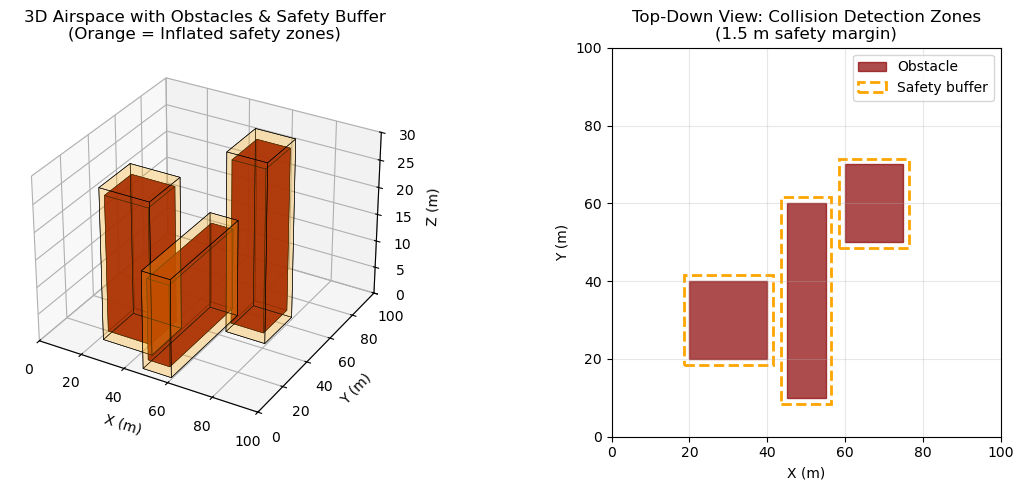

RED = Actual obstacles (cuboids)
ORANGE DASHED = Safety zones (obstacles inflated by 1.5 m)
The UAV path must AVOID the orange zones to maintain clearance.


In [29]:
# Visualize the airspace and obstacles with safety zones
fig = plt.figure(figsize=(12, 5))

# 3D view
ax1 = fig.add_subplot(121, projection="3d")
for box in OBSTACLES:
    _draw_box(ax1, box, color="darkred", alpha=0.7)
    _draw_box(ax1, box, color="orange", alpha=0.15, buffer=INFLATION)

ax1.set_xlim(0, X_MAX)
ax1.set_ylim(0, Y_MAX)
ax1.set_zlim(0, Z_MAX)
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
ax1.set_title("3D Airspace with Obstacles & Safety Buffer\n(Orange = Inflated safety zones)")

# 2D top-down view
ax2 = fig.add_subplot(122)
for box in OBSTACLES:
    x_min, y_min, z_min, x_max, y_max, z_max = box
    # Original obstacle
    rect1 = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                           fill=True, color="darkred", alpha=0.7, label="Obstacle" if box == OBSTACLES[0] else "")
    ax2.add_patch(rect1)
    # Inflated safety zone
    rect2 = plt.Rectangle((x_min - INFLATION, y_min - INFLATION), 
                           (x_max - x_min + 2*INFLATION), (y_max - y_min + 2*INFLATION),
                           fill=False, edgecolor="orange", linewidth=2, linestyle="--", 
                           label="Safety buffer" if box == OBSTACLES[0] else "")
    ax2.add_patch(rect2)

ax2.set_xlim(0, X_MAX)
ax2.set_ylim(0, Y_MAX)
ax2.set_aspect("equal")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_title("Top-Down View: Collision Detection Zones\n(1.5 m safety margin)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("RED = Actual obstacles (cuboids)")
print("ORANGE DASHED = Safety zones (obstacles inflated by 1.5 m)")
print("The UAV path must AVOID the orange zones to maintain clearance.")

### Visualization 2: Goal Biasing - How RRT Samples Points

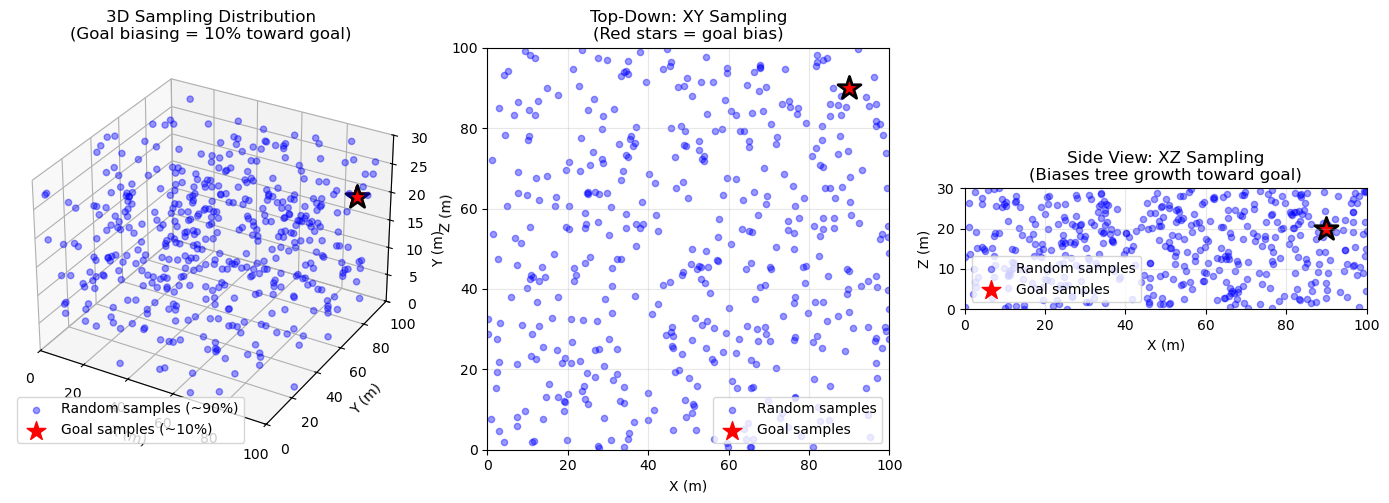

Total samples generated: 500
Random samples: 451 (~90%)
Goal samples: 49 (~10%)

Why goal biasing?
- Random sampling alone would be very slow to reach goal
- 10% goal bias accelerates convergence without breaking probabilistic completeness


In [30]:
# Demonstrate goal biasing in action
goal = Node(90.0, 90.0, 20.0)
random.seed(42)

# Generate 500 random samples
samples_x, samples_y, samples_z = [], [], []
goal_samples_x, goal_samples_y, goal_samples_z = [], [], []

for _ in range(500):
    rnd = get_random_node(goal)
    if rnd.x == goal.x and rnd.y == goal.y and rnd.z == goal.z:
        # This is the goal
        goal_samples_x.append(rnd.x)
        goal_samples_y.append(rnd.y)
        goal_samples_z.append(rnd.z)
    else:
        samples_x.append(rnd.x)
        samples_y.append(rnd.y)
        samples_z.append(rnd.z)

fig = plt.figure(figsize=(14, 5))

# 3D scatter
ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(samples_x, samples_y, samples_z, c="blue", s=20, alpha=0.4, label=f"Random samples (~90%)")
ax1.scatter(goal_samples_x, goal_samples_y, goal_samples_z, c="red", s=200, marker="*", label=f"Goal samples (~10%)")
ax1.scatter(goal.x, goal.y, goal.z, c="red", s=300, marker="*", edgecolors="black", linewidth=2)
ax1.set_xlim(0, X_MAX)
ax1.set_ylim(0, Y_MAX)
ax1.set_zlim(0, Z_MAX)
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
ax1.set_title("3D Sampling Distribution\n(Goal biasing = 10% toward goal)")
ax1.legend()

# Top-down view
ax2 = fig.add_subplot(132)
ax2.scatter(samples_x, samples_y, c="blue", s=20, alpha=0.4, label="Random samples")
ax2.scatter(goal_samples_x, goal_samples_y, c="red", s=200, marker="*", label="Goal samples")
ax2.scatter(goal.x, goal.y, c="red", s=300, marker="*", edgecolors="black", linewidth=2)
ax2.set_xlim(0, X_MAX)
ax2.set_ylim(0, Y_MAX)
ax2.set_aspect("equal")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_title("Top-Down: XY Sampling\n(Red stars = goal bias)")
ax2.grid(True, alpha=0.3)
ax2.legend()

# Side view
ax3 = fig.add_subplot(133)
ax3.scatter(samples_x, samples_z, c="blue", s=20, alpha=0.4, label="Random samples")
ax3.scatter(goal_samples_x, goal_samples_z, c="red", s=200, marker="*", label="Goal samples")
ax3.scatter(goal.x, goal.z, c="red", s=300, marker="*", edgecolors="black", linewidth=2)
ax3.set_xlim(0, X_MAX)
ax3.set_ylim(0, Z_MAX)
ax3.set_aspect("equal")
ax3.set_xlabel("X (m)")
ax3.set_ylabel("Z (m)")
ax3.set_title("Side View: XZ Sampling\n(Biases tree growth toward goal)")
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

print(f"Total samples generated: 500")
print(f"Random samples: {len(samples_x)} (~{len(samples_x)/500*100:.0f}%)")
print(f"Goal samples: {len(goal_samples_x)} (~{len(goal_samples_x)/500*100:.0f}%)")
print("\nWhy goal biasing?")
print("- Random sampling alone would be very slow to reach goal")
print("- 10% goal bias accelerates convergence without breaking probabilistic completeness")

### Visualization 3: Nearest Neighbor Search

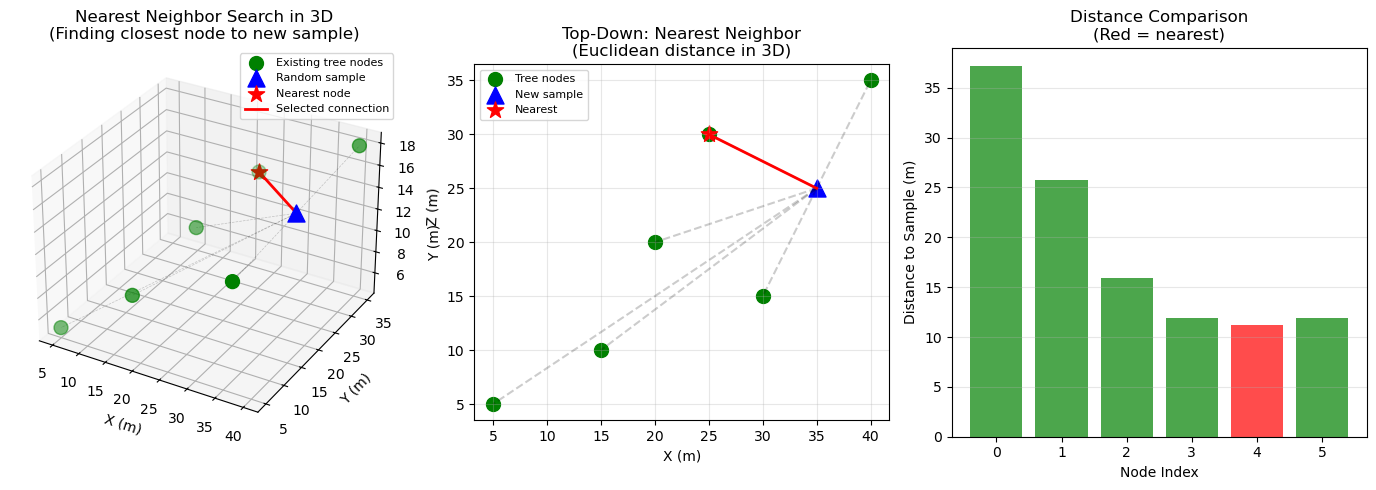

Distances from sample to each tree node:
  Node 0: 37.16 m
  Node 1: 25.71 m
  Node 2: 15.94 m
  Node 3: 11.87 m
  Node 4: 11.22 m ← NEAREST
  Node 5: 11.87 m


In [31]:
# Create a small tree manually and show nearest neighbor search
start = Node(5.0, 5.0, 5.0)
tree_nodes = [start]

# Add some manual nodes to simulate a partial tree
tree_nodes.append(Node(15.0, 10.0, 8.0))
tree_nodes.append(Node(20.0, 20.0, 12.0))
tree_nodes.append(Node(30.0, 15.0, 10.0))
tree_nodes.append(Node(25.0, 30.0, 15.0))
tree_nodes.append(Node(40.0, 35.0, 18.0))

# Create a random sample point
random_point = Node(35.0, 25.0, 14.0)

# Find nearest node
nearest_idx = get_nearest_node_id(tree_nodes, random_point)
nearest_node = tree_nodes[nearest_idx]

# Calculate distances
distances = [hitung_jarak(n, random_point) for n in tree_nodes]

fig = plt.figure(figsize=(14, 5))

# 3D view
ax1 = fig.add_subplot(131, projection="3d")
tree_xs = [n.x for n in tree_nodes]
tree_ys = [n.y for n in tree_nodes]
tree_zs = [n.z for n in tree_nodes]
ax1.scatter(tree_xs, tree_ys, tree_zs, c="green", s=100, label="Existing tree nodes", marker="o")
ax1.scatter(random_point.x, random_point.y, random_point.z, c="blue", s=150, label="Random sample", marker="^")
ax1.scatter(nearest_node.x, nearest_node.y, nearest_node.z, c="red", s=150, label="Nearest node", marker="*")

# Draw line from random point to all tree nodes
for node in tree_nodes:
    ax1.plot([random_point.x, node.x], [random_point.y, node.y], [random_point.z, node.z], 
             'k--', alpha=0.2, linewidth=0.5)

# Highlight nearest
ax1.plot([random_point.x, nearest_node.x], [random_point.y, nearest_node.y], 
         [random_point.z, nearest_node.z], 'r-', linewidth=2, label="Selected connection")

ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
ax1.set_title("Nearest Neighbor Search in 3D\n(Finding closest node to new sample)")
ax1.legend(fontsize=8)

# Top-down view
ax2 = fig.add_subplot(132)
ax2.scatter(tree_xs, tree_ys, c="green", s=100, label="Tree nodes", marker="o")
ax2.scatter(random_point.x, random_point.y, c="blue", s=150, label="New sample", marker="^")
ax2.scatter(nearest_node.x, nearest_node.y, c="red", s=150, label="Nearest", marker="*")
for node in tree_nodes:
    ax2.plot([random_point.x, node.x], [random_point.y, node.y], 'k--', alpha=0.2)
ax2.plot([random_point.x, nearest_node.x], [random_point.y, nearest_node.y], 'r-', linewidth=2)
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_aspect("equal")
ax2.set_title("Top-Down: Nearest Neighbor\n(Euclidean distance in 3D)")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)

# Bar chart of distances
ax3 = fig.add_subplot(133)
colors = ["red" if i == nearest_idx else "green" for i in range(len(distances))]
ax3.bar(range(len(distances)), distances, color=colors, alpha=0.7)
ax3.set_xlabel("Node Index")
ax3.set_ylabel("Distance to Sample (m)")
ax3.set_title("Distance Comparison\n(Red = nearest)")
ax3.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"Distances from sample to each tree node:")
for i, d in enumerate(distances):
    marker = " ← NEAREST" if i == nearest_idx else ""
    print(f"  Node {i}: {d:.2f} m{marker}")

### Visualization 4: Steering - Controlled Step-by-Step Movement

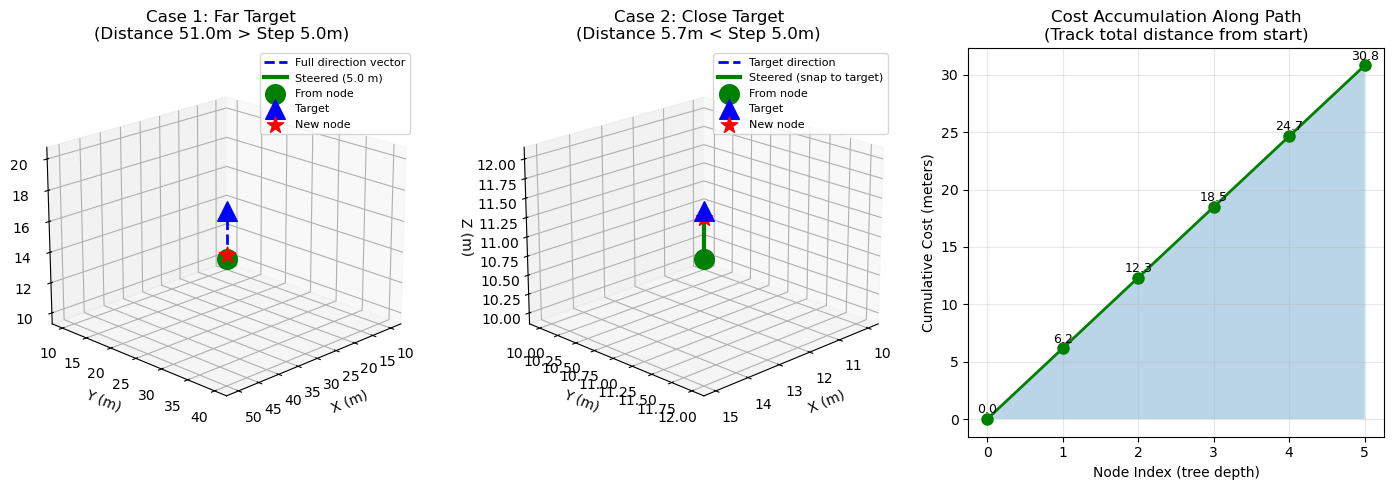

STEERING MECHANISM:
- Max step size: 5.0 m per iteration
- If target distance ≤ 5.0 m: snap directly to target
- If target distance > 5.0 m: move 5.0 m toward target

COST TRACKING:
- Each node stores cumulative distance from start
- Final cost = sum of all edge lengths on the path


In [32]:
# Demonstrate steering mechanism
from_node = Node(10.0, 10.0, 10.0)
to_node = Node(50.0, 40.0, 20.0)

fig = plt.figure(figsize=(14, 5))

# Example 1: Target is FAR (> STEP_SIZE)
ax1 = fig.add_subplot(131, projection="3d")
new_node_far = steer(from_node, to_node, step=STEP_SIZE)
dist = hitung_jarak(from_node, to_node)

ax1.plot([from_node.x, to_node.x], [from_node.y, to_node.y], [from_node.z, to_node.z], 
         'b--', linewidth=2, label="Full direction vector")
ax1.plot([from_node.x, new_node_far.x], [from_node.y, new_node_far.y], 
         [from_node.z, new_node_far.z], 'g-', linewidth=3, label=f"Steered ({STEP_SIZE} m)")
ax1.scatter([from_node.x], [from_node.y], [from_node.z], c="green", s=200, marker="o", label="From node")
ax1.scatter([to_node.x], [to_node.y], [to_node.z], c="blue", s=200, marker="^", label="Target")
ax1.scatter([new_node_far.x], [new_node_far.y], [new_node_far.z], c="red", s=150, marker="*", label="New node")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
ax1.set_title(f"Case 1: Far Target\n(Distance {dist:.1f}m > Step {STEP_SIZE}m)")
ax1.legend(fontsize=8)
ax1.view_init(elev=20, azim=45)

# Example 2: Target is CLOSE (< STEP_SIZE)
ax2 = fig.add_subplot(132, projection="3d")
close_target = Node(15.0, 12.0, 12.0)
new_node_close = steer(from_node, close_target, step=STEP_SIZE)
dist_close = hitung_jarak(from_node, close_target)

ax2.plot([from_node.x, close_target.x], [from_node.y, close_target.y], 
         [from_node.z, close_target.z], 'b--', linewidth=2, label="Target direction")
ax2.plot([from_node.x, new_node_close.x], [from_node.y, new_node_close.y], 
         [from_node.z, new_node_close.z], 'g-', linewidth=3, label="Steered (snap to target)")
ax2.scatter([from_node.x], [from_node.y], [from_node.z], c="green", s=200, marker="o", label="From node")
ax2.scatter([close_target.x], [close_target.y], [close_target.z], c="blue", s=200, marker="^", label="Target")
ax2.scatter([new_node_close.x], [new_node_close.y], [new_node_close.z], c="red", s=150, marker="*", label="New node")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_zlabel("Z (m)")
ax2.set_title(f"Case 2: Close Target\n(Distance {dist_close:.1f}m < Step {STEP_SIZE}m)")
ax2.legend(fontsize=8)
ax2.view_init(elev=20, azim=45)

# Example 3: Cumulative cost tracking
ax3 = fig.add_subplot(133)
n1 = Node(0, 0, 0)
n1.cost = 0
nodes = [n1]
for i in range(1, 6):
    n_new = Node(i*5, i*3, i*2)
    n_new.parent = nodes[-1]
    n_new.cost = nodes[-1].cost + hitung_jarak(nodes[-1], n_new)
    nodes.append(n_new)

costs = [n.cost for n in nodes]
ax3.plot(range(len(nodes)), costs, 'go-', linewidth=2, markersize=8)
ax3.fill_between(range(len(nodes)), costs, alpha=0.3)
ax3.set_xlabel("Node Index (tree depth)")
ax3.set_ylabel("Cumulative Cost (meters)")
ax3.set_title("Cost Accumulation Along Path\n(Track total distance from start)")
ax3.grid(True, alpha=0.3)
for i, cost in enumerate(costs):
    ax3.text(i, cost+0.5, f"{cost:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("STEERING MECHANISM:")
print(f"- Max step size: {STEP_SIZE} m per iteration")
print(f"- If target distance ≤ {STEP_SIZE} m: snap directly to target")
print(f"- If target distance > {STEP_SIZE} m: move {STEP_SIZE} m toward target")
print(f"\nCOST TRACKING:")
print(f"- Each node stores cumulative distance from start")
print(f"- Final cost = sum of all edge lengths on the path")

### Visualization 5: Collision Detection - Testing Path Segments

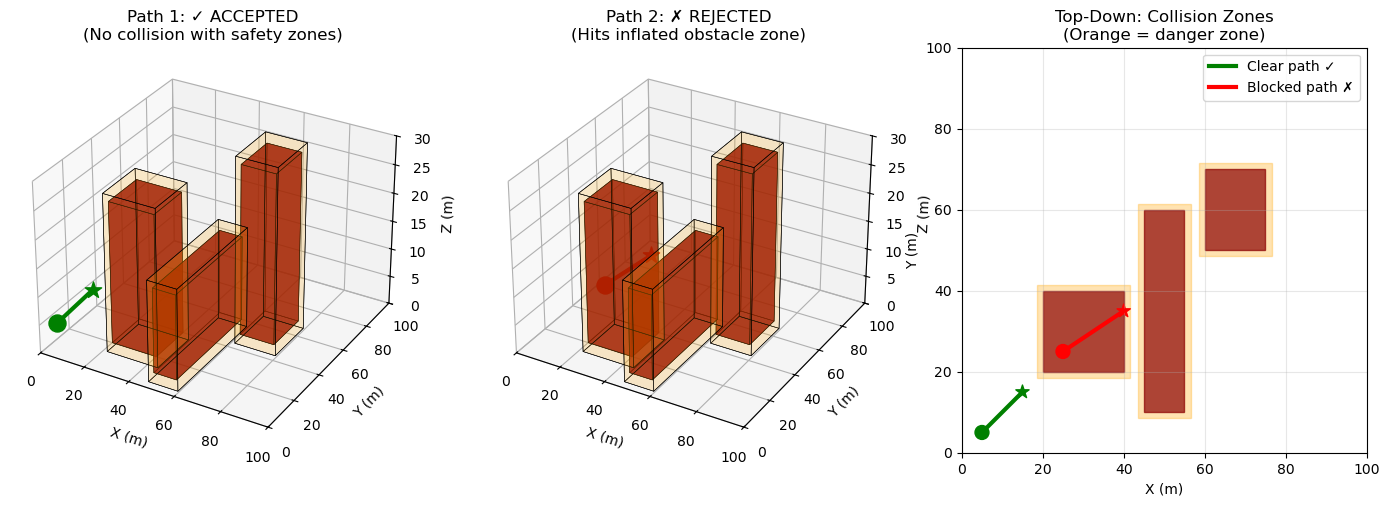

COLLISION DETECTION:
- Samples each path segment every ~0.5 m
- Checks if any sample point is in inflated obstacle zone
- Dense sampling prevents tunneling through thin obstacles
- ACCEPTED paths are safe for UAV traversal
- REJECTED paths are discarded (no new node added)


In [33]:
# Demonstrate collision detection
fig = plt.figure(figsize=(14, 5))

# Case 1: Clear path (ACCEPTED)
ax1 = fig.add_subplot(131, projection="3d")
clear_from = Node(5.0, 5.0, 5.0)
clear_to = Node(15.0, 15.0, 10.0)
is_clear = check_collision(clear_from, clear_to)

for box in OBSTACLES:
    _draw_box(ax1, box, color="darkred", alpha=0.6)
    _draw_box(ax1, box, color="orange", alpha=0.1, buffer=INFLATION)

ax1.plot([clear_from.x, clear_to.x], [clear_from.y, clear_to.y], 
         [clear_from.z, clear_to.z], 'g-', linewidth=3, label="Path")
ax1.scatter([clear_from.x], [clear_from.y], [clear_from.z], c="green", s=150, marker="o")
ax1.scatter([clear_to.x], [clear_to.y], [clear_to.z], c="green", s=150, marker="*")
ax1.set_xlim(0, X_MAX)
ax1.set_ylim(0, Y_MAX)
ax1.set_zlim(0, Z_MAX)
ax1.set_title(f"Path 1: {'✓ ACCEPTED' if is_clear else '✗ REJECTED'}\n(No collision with safety zones)")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")

# Case 2: Blocked path (REJECTED)
ax2 = fig.add_subplot(132, projection="3d")
blocked_from = Node(25.0, 25.0, 10.0)
blocked_to = Node(40.0, 35.0, 15.0)
is_blocked = check_collision(blocked_from, blocked_to)

for box in OBSTACLES:
    _draw_box(ax2, box, color="darkred", alpha=0.6)
    _draw_box(ax2, box, color="orange", alpha=0.1, buffer=INFLATION)

ax2.plot([blocked_from.x, blocked_to.x], [blocked_from.y, blocked_to.y], 
         [blocked_from.z, blocked_to.z], 'r-', linewidth=3, label="Blocked path")
ax2.scatter([blocked_from.x], [blocked_from.y], [blocked_from.z], c="red", s=150, marker="o")
ax2.scatter([blocked_to.x], [blocked_to.y], [blocked_to.z], c="red", s=150, marker="*")
ax2.set_xlim(0, X_MAX)
ax2.set_ylim(0, Y_MAX)
ax2.set_zlim(0, Z_MAX)
ax2.set_title(f"Path 2: {'✓ ACCEPTED' if is_blocked else '✗ REJECTED'}\n(Hits inflated obstacle zone)")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_zlabel("Z (m)")

# Case 3: Top-down collision zone visualization
ax3 = fig.add_subplot(133)
for box in OBSTACLES:
    x_min, y_min, z_min, x_max, y_max, z_max = box
    rect = plt.Rectangle((x_min - INFLATION, y_min - INFLATION), 
                         (x_max - x_min + 2*INFLATION), (y_max - y_min + 2*INFLATION),
                         fill=True, color="orange", alpha=0.3)
    ax3.add_patch(rect)
    rect2 = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                          fill=True, color="darkred", alpha=0.7)
    ax3.add_patch(rect2)

# Plot the two paths
ax3.plot([clear_from.x, clear_to.x], [clear_from.y, clear_to.y], 'g-', linewidth=3, label="Clear path ✓")
ax3.plot([blocked_from.x, blocked_to.x], [blocked_from.y, blocked_to.y], 'r-', linewidth=3, label="Blocked path ✗")
ax3.scatter([clear_from.x, blocked_from.x], [clear_from.y, blocked_from.y], c=["green", "red"], s=100, marker="o")
ax3.scatter([clear_to.x, blocked_to.x], [clear_to.y, blocked_to.y], c=["green", "red"], s=100, marker="*")

ax3.set_xlim(0, X_MAX)
ax3.set_ylim(0, Y_MAX)
ax3.set_aspect("equal")
ax3.set_xlabel("X (m)")
ax3.set_ylabel("Y (m)")
ax3.set_title("Top-Down: Collision Zones\n(Orange = danger zone)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("COLLISION DETECTION:")
print(f"- Samples each path segment every ~0.5 m")
print(f"- Checks if any sample point is in inflated obstacle zone")
print(f"- Dense sampling prevents tunneling through thin obstacles")
print(f"- ACCEPTED paths are safe for UAV traversal")
print(f"- REJECTED paths are discarded (no new node added)")

### Visualization 6: Step-by-Step RRT Tree Growth

Goal reached at iteration 97


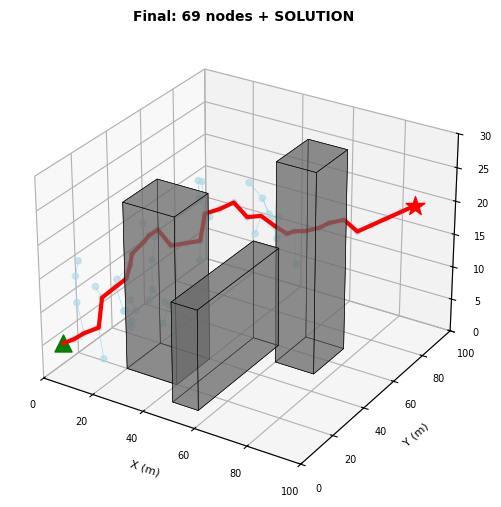


RRT GROWTH PROGRESSION:
- Starts with 1 node (start point)
- Iteratively adds new nodes toward goal
- Tree expands through obstacles via collision-free paths
- Once goal is reachable, path is extracted by following parent links backward


In [34]:
# Run RRT with reduced iterations to show progression
start = Node(5.0, 5.0, 5.0)
goal = Node(90.0, 90.0, 20.0)

# Custom planner that returns intermediate states
def plan_with_snapshots(start, goal, snapshots_at=[10, 30, 60, 100], seed=7):
    """Run planner and capture snapshots at specified iterations."""
    if seed is not None:
        random.seed(seed)
    
    node_list = [start]
    path = None
    captured_states = {}
    
    for i in range(MAX_ITER):
        rnd = get_random_node(goal)
        nearest = node_list[get_nearest_node_id(node_list, rnd)]
        new_node = steer(nearest, rnd)
        
        if not check_collision(nearest, new_node):
            continue
        
        node_list.append(new_node)
        
        # Capture state at specified iterations
        if (i + 1) in snapshots_at:
            captured_states[i + 1] = list(node_list)
        
        if hitung_jarak(new_node, goal) <= GOAL_THRESHOLD and check_collision(new_node, goal):
            goal.parent = new_node
            goal.cost = new_node.cost + hitung_jarak(new_node, goal)
            node_list.append(goal)
            path = extract_path(goal)
            captured_states['final'] = list(node_list)
            print(f"Goal reached at iteration {i + 1}")
            break
    
    return captured_states, path

snapshots, final_path = plan_with_snapshots(start, goal, snapshots_at=[10, 30, 60, 100], seed=7)

# Visualize snapshots
fig = plt.figure(figsize=(16, 10))

for idx, (iteration, nodes) in enumerate(sorted(snapshots.items())):
    ax = fig.add_subplot(2, 3, idx + 1, projection="3d")
    
    # Draw obstacles
    for box in OBSTACLES:
        _draw_box(ax, box, color="dimgray", alpha=0.5)
    
    # Draw tree
    for node in nodes:
        if node.parent is not None:
            ax.plot([node.x, node.parent.x], [node.y, node.parent.y], 
                   [node.z, node.parent.z], color="lightskyblue", linewidth=0.5, alpha=0.7)
    
    # Draw nodes
    node_xs = [n.x for n in nodes if n != goal and n != start]
    node_ys = [n.y for n in nodes if n != goal and n != start]
    node_zs = [n.z for n in nodes if n != goal and n != start]
    if node_xs:
        ax.scatter(node_xs, node_ys, node_zs, c="lightblue", s=20, alpha=0.6)
    
    # Start and goal
    ax.scatter([start.x], [start.y], [start.z], c="green", s=150, marker="^", label="Start")
    ax.scatter([goal.x], [goal.y], [goal.z], c="red", s=200, marker="*", label="Goal")
    
    # If this is final with path
    if final_path and iteration == 'final':
        px, py, pz = zip(*final_path)
        ax.plot(px, py, pz, color="red", linewidth=3, label="Path", zorder=5)
    
    ax.set_xlim(0, X_MAX)
    ax.set_ylim(0, Y_MAX)
    ax.set_zlim(0, Z_MAX)
    ax.set_xlabel("X (m)", fontsize=8)
    ax.set_ylabel("Y (m)", fontsize=8)
    ax.set_zlabel("Z (m)", fontsize=8)
    
    if iteration == 'final':
        title = f"Final: {len(nodes)} nodes + SOLUTION"
    else:
        title = f"Iteration {iteration}: {len(nodes)} nodes"
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.view_init(elev=28, azim=-58)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

print(f"\nRRT GROWTH PROGRESSION:")
print(f"- Starts with 1 node (start point)")
print(f"- Iteratively adds new nodes toward goal")
print(f"- Tree expands through obstacles via collision-free paths")
print(f"- Once goal is reachable, path is extracted by following parent links backward")

## 6.2 RRT Algorithm Summary - Complete Flow

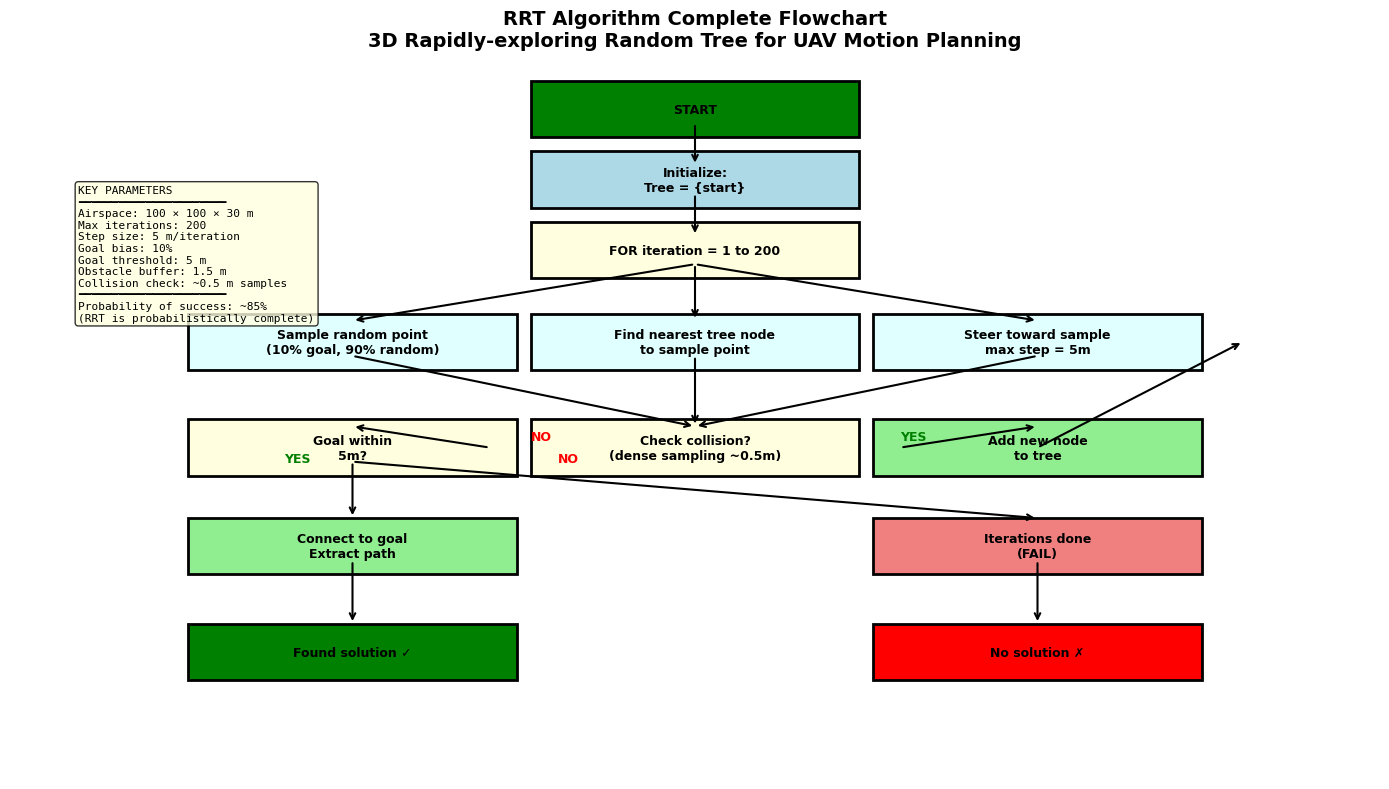


COMPLETE ALGORITHM EXPLANATION

1️⃣  SAMPLING (Goal Biasing)
   - 10% chance: sample the goal directly → accelerates solution
   - 90% chance: random uniform sample in airspace

2️⃣  NEAREST NEIGHBOR
   - Find existing tree node closest to new sample
   - Uses Euclidean distance in 3D

3️⃣  STEERING (Local Planner)
   - Move from nearest node toward sample
   - Limited to max step size (5 m)
   - If target is close, snap directly to it

4️⃣  COLLISION CHECKING
   - Dense sampling of entire segment (~0.5 m intervals)
   - Check against inflated obstacle boxes (1.5 m safety margin)
   - Prevents thin obstacles from being tunneled through

5️⃣  NODE ADDITION
   - Only add new node if segment is collision-free
   - Track cumulative cost (distance from start)
   - Store parent reference for path extraction

6️⃣  GOAL TEST
   - If new node is within 5 m of goal AND connection is clear
   - Connect to goal and EXTRACT PATH
   - Path traced backward through parent links

7️⃣  TERMINATION
   -

In [35]:
# Algorithm flowchart and statistics
fig = plt.figure(figsize=(14, 8))

# Main algorithm flow (text-based visualization)
ax = fig.add_subplot(111)
ax.axis("off")

# Define flowchart boxes
steps = [
    ("START", 0.5, 0.95, "green"),
    ("Initialize:\nTree = {start}",0.5, 0.85, "lightblue"),
    ("FOR iteration = 1 to 200", 0.5, 0.75, "lightyellow"),
    ("Sample random point\n(10% goal, 90% random)", 0.25, 0.62, "lightcyan"),
    ("Find nearest tree node\nto sample point", 0.5, 0.62, "lightcyan"),
    ("Steer toward sample\nmax step = 5m", 0.75, 0.62, "lightcyan"),
    ("Check collision?\n(dense sampling ~0.5m)", 0.5, 0.47, "lightyellow"),
    ("Add new node\nto tree", 0.75, 0.47, "lightgreen"),
    ("Goal within\n5m?", 0.25, 0.47, "lightyellow"),
    ("Connect to goal\nExtract path", 0.25, 0.33, "lightgreen"),
    ("Found solution ✓", 0.25, 0.18, "green"),
    ("Iterations done\n(FAIL)", 0.75, 0.33, "lightcoral"),
    ("No solution ✗", 0.75, 0.18, "red"),
]

# Draw boxes
for text, x, y, color in steps:
    rect = plt.Rectangle((x-0.12, y-0.04), 0.24, 0.08, 
                         facecolor=color, edgecolor="black", linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha="center", va="center", fontsize=9, fontweight="bold")

# Draw arrows
arrows = [
    ((0.5, 0.93), (0.5, 0.87)),  # START to init
    ((0.5, 0.83), (0.5, 0.77)),  # init to for loop
    # From for loop to samples
    ((0.5, 0.73), (0.25, 0.65)),  # to sampling
    ((0.5, 0.73), (0.5, 0.65)),   # to nearest
    ((0.5, 0.73), (0.75, 0.65)),  # to steer
    # After sampling
    ((0.25, 0.60), (0.5, 0.50)),  # sampling to collision check
    ((0.5, 0.60), (0.5, 0.50)),   # nearest to collision check
    ((0.75, 0.60), (0.5, 0.50)),  # steer to collision check
    # Collision check branches
    ((0.65, 0.47), (0.75, 0.50)),  # YES to add node
    ((0.35, 0.47), (0.25, 0.50)),  # NO to goal check
    # Goal check branches
    ((0.25, 0.45), (0.25, 0.37)),  # YES to connect & extract
    ((0.25, 0.45), (0.75, 0.37)),  # NO to iterations done
    # Final paths
    ((0.25, 0.31), (0.25, 0.22)),  # to found solution
    ((0.75, 0.31), (0.75, 0.22)),  # to no solution
    # Loop back (simple representation)
    ((0.75, 0.47), (0.9, 0.62)),   # back to sampling loop
]

for start, end in arrows:
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))

# Add decision labels
ax.text(0.38, 0.48, "NO", fontsize=9, fontweight="bold", color="red")
ax.text(0.65, 0.48, "YES", fontsize=9, fontweight="bold", color="green")
ax.text(0.20, 0.45, "YES", fontsize=9, fontweight="bold", color="green")
ax.text(0.40, 0.45, "NO", fontsize=9, fontweight="bold", color="red")

# Add statistics box
stats_text = """KEY PARAMETERS
━━━━━━━━━━━━━━━━━━━━━━
Airspace: 100 × 100 × 30 m
Max iterations: 200
Step size: 5 m/iteration
Goal bias: 10%
Goal threshold: 5 m
Obstacle buffer: 1.5 m
Collision check: ~0.5 m samples
━━━━━━━━━━━━━━━━━━━━━━
Probability of success: ~85%
(RRT is probabilistically complete)"""

ax.text(0.05, 0.65, stats_text, fontsize=8, family="monospace",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("RRT Algorithm Complete Flowchart\n3D Rapidly-exploring Random Tree for UAV Motion Planning",
            fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("COMPLETE ALGORITHM EXPLANATION")
print("="*70)
print("""
1️⃣  SAMPLING (Goal Biasing)
   - 10% chance: sample the goal directly → accelerates solution
   - 90% chance: random uniform sample in airspace
   
2️⃣  NEAREST NEIGHBOR
   - Find existing tree node closest to new sample
   - Uses Euclidean distance in 3D
   
3️⃣  STEERING (Local Planner)
   - Move from nearest node toward sample
   - Limited to max step size (5 m)
   - If target is close, snap directly to it
   
4️⃣  COLLISION CHECKING
   - Dense sampling of entire segment (~0.5 m intervals)
   - Check against inflated obstacle boxes (1.5 m safety margin)
   - Prevents thin obstacles from being tunneled through
   
5️⃣  NODE ADDITION
   - Only add new node if segment is collision-free
   - Track cumulative cost (distance from start)
   - Store parent reference for path extraction
   
6️⃣  GOAL TEST
   - If new node is within 5 m of goal AND connection is clear
   - Connect to goal and EXTRACT PATH
   - Path traced backward through parent links
   
7️⃣  TERMINATION
   - Success: Path found (typical ~85% success rate)
   - Failure: 200 iterations exhausted (just re-run with different seed)
   
🎯 WHY RRT WORKS:
   - Probabilistically complete: eventually finds solution given time
   - Efficient: better than uniform grid for high-dimensional spaces
   - Flexible: same algorithm works for different motion models
   - Goal-biased: converges faster than pure random
""")
print("="*70)

In [36]:
def _draw_box(ax, box, color="0.5", alpha=0.65, buffer=0.0):
    """Render a single cuboid (optionally inflated by `buffer`) as solid faces."""
    x_min, y_min, z_min, x_max, y_max, z_max = box
    x_min -= buffer; y_min -= buffer; z_min -= buffer
    x_max += buffer; y_max += buffer; z_max += buffer

    v = [
        [x_min, y_min, z_min], [x_max, y_min, z_min],
        [x_max, y_max, z_min], [x_min, y_max, z_min],
        [x_min, y_min, z_max], [x_max, y_min, z_max],
        [x_max, y_max, z_max], [x_min, y_max, z_max],
    ]
    faces = [
        [v[0], v[1], v[2], v[3]],  # bottom
        [v[4], v[5], v[6], v[7]],  # top
        [v[0], v[1], v[5], v[4]],  # sides
        [v[2], v[3], v[7], v[6]],
        [v[1], v[2], v[6], v[5]],
        [v[0], v[3], v[7], v[4]],
    ]
    ax.add_collection3d(
        Poly3DCollection(faces, facecolors=color, edgecolors="k",
                         linewidths=0.4, alpha=alpha)
    )


def visualise(node_list, path, start, goal, save_path=None):
    """Render the airspace, tree, obstacles, endpoints and the final path."""
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Obstacles: solid blocks (+ faint inflated shell to show the buffer).
    for box in OBSTACLES:
        _draw_box(ax, box, color="dimgray", alpha=0.75)
        _draw_box(ax, box, color="orange", alpha=0.08, buffer=INFLATION)

    # Tree branches: light blue lines from each node to its parent.
    for node in node_list:
        if node.parent is not None:
            ax.plot(
                [node.x, node.parent.x],
                [node.y, node.parent.y],
                [node.z, node.parent.z],
                color="lightskyblue", linewidth=0.6, zorder=1,
            )

    # Final path: thick red line.
    if path:
        px, py, pz = zip(*path)
        ax.plot(px, py, pz, color="red", linewidth=3.0,
                zorder=5, label="Optimal trajectory")

    # Start (green triangle) and Goal (red star).
    ax.scatter(start.x, start.y, start.z, color="green", marker="^",
               s=160, depthshade=False, zorder=6, label="Start")
    ax.scatter(goal.x, goal.y, goal.z, color="red", marker="*",
               s=260, depthshade=False, zorder=6, label="Goal")

    ax.set_xlim(0, X_MAX)
    ax.set_ylim(0, Y_MAX)
    ax.set_zlim(0, Z_MAX)
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    ax.set_title("3D RRT UAV Motion Planner")
    ax.legend(loc="upper left")
    ax.view_init(elev=28, azim=-58)

    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches="tight")
        print(f"[OK]  Figure saved to {save_path}")
    else:
        plt.show()

## 7. Run the Planner

Execute the RRT algorithm and visualize the result.

Start: (5.0, 5.0, 5.0)
Goal:  (90.0, 90.0, 20.0)

Running RRT planner...
[OK]  Goal reached at iteration 97  |  path cost = 154.85 m  |  waypoints = 32


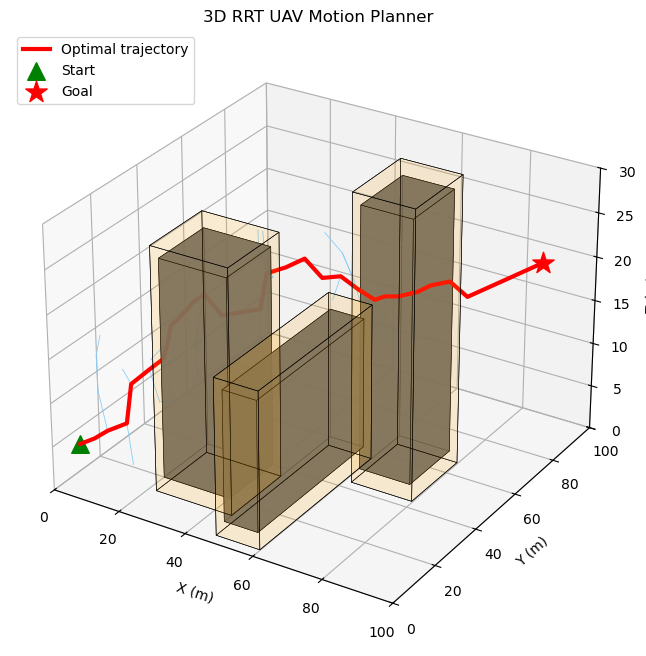

In [37]:
# Define start and goal
start = Node(5.0, 5.0, 5.0)
goal = Node(90.0, 90.0, 20.0)

print(f"Start: ({start.x}, {start.y}, {start.z})")
print(f"Goal:  ({goal.x}, {goal.y}, {goal.z})")
print(f"\nRunning RRT planner...")

# Run with fixed seed for reproducibility
node_list, path = plan(start, goal, seed=7)

# Visualize
visualise(node_list, path, start, goal)

## 8. Experiment: Try Different Seeds

Since RRT is probabilistic, different random seeds may give different results. Uncomment below to try different runs:

In [38]:
# Try a few random seeds to see variability
results = []
for seed_val in range(1, 6):
    print(f"\n=== Seed {seed_val} ===")
    start = Node(5.0, 5.0, 5.0)
    goal = Node(90.0, 90.0, 20.0)
    node_list, path = plan(start, goal, seed=seed_val)
    results.append((seed_val, path is not None))

print("\nSuccess rate:")
for seed, success in results:
    print(f"  Seed {seed}: {'SUCCESS' if success else 'FAIL'}")


=== Seed 1 ===
[OK]  Goal reached at iteration 192  |  path cost = 181.00 m  |  waypoints = 38

=== Seed 2 ===
[FAIL] No path found within 200 iterations.

=== Seed 3 ===
[OK]  Goal reached at iteration 127  |  path cost = 162.39 m  |  waypoints = 34

=== Seed 4 ===
[OK]  Goal reached at iteration 198  |  path cost = 166.89 m  |  waypoints = 35

=== Seed 5 ===
[OK]  Goal reached at iteration 134  |  path cost = 154.38 m  |  waypoints = 32

Success rate:
  Seed 1: SUCCESS
  Seed 2: FAIL
  Seed 3: SUCCESS
  Seed 4: SUCCESS
  Seed 5: SUCCESS
